In [1]:
import warnings
warnings.filterwarnings ('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [6]:
import pandas as pd

# Load the raw diabetes dataset from the local file path
url = "C:\\Users\\IT24102555\\Downloads\\Lab Sheet 04\\Lab Sheet 04\\diabetes.tab.txt"
data = pd.read_csv(url, sep='\t')  # You missed the '=' sign here

# Display column headers
print("Original column headers:")
print(list(data.columns))


Original column headers:
['AGE', 'SEX', 'BMI', 'BP', 'S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'Y']


In [9]:
#Rename headers for clarity
new_columns = {
    'AGE': 'Age', 
    'SEX': 'Sex', 
    'BMI': 'BMI', 
    'BP': 'Blood Pressure',
    'S1': 'SerumCholesterol', 
    'S2': 'SerumLDL', 
    'S3': 'SerumHDL', 
    '54': 'SerumTCH', 
    'S5': 'SerumLTG', 
    'S6': 'SerumGlucose', 
    'Y': 'DiseaseProgression'
    }
data.rename(columns=new_columns, inplace=True)
# Display top 5 rows
print("\nTop 5 rows of dataset")
print(data.head())


Top 5 rows of dataset
   Age  Sex   BMI  Blood Pressure  SerumCholesterol  SerumLDL  SerumHDL   S4  \
0   59    2  32.1           101.0               157      93.2      38.0  4.0   
1   48    1  21.6            87.0               183     103.2      70.0  3.0   
2   72    2  30.5            93.0               156      93.6      41.0  4.0   
3   24    1  25.3            84.0               198     131.4      40.0  5.0   
4   50    1  23.0           101.0               192     125.4      52.0  4.0   

   SerumLTG  SerumGlucose  DiseaseProgression  
0    4.8598            87                 151  
1    3.8918            69                  75  
2    4.6728            85                 141  
3    4.8903            89                 206  
4    4.2905            80                 135  


In [10]:
# Separate features (X) and target (y)
X= data.drop(columns=['DiseaseProgression'])
# Features
y = data['DiseaseProgression']
# Target
# Convert features to pandas DataFrame
pd_X= pd.DataFrame (X)
# Convert target to pandas Series for display
pd_Y = pd.Series (y)
# Display top 5 rows
print("\nTop 5 rows of Features")
print(pd_X.head(5))
print("\nTop 5 rows of Target")
print(pd_Y.head(5))


Top 5 rows of Features
   Age  Sex   BMI  Blood Pressure  SerumCholesterol  SerumLDL  SerumHDL   S4  \
0   59    2  32.1           101.0               157      93.2      38.0  4.0   
1   48    1  21.6            87.0               183     103.2      70.0  3.0   
2   72    2  30.5            93.0               156      93.6      41.0  4.0   
3   24    1  25.3            84.0               198     131.4      40.0  5.0   
4   50    1  23.0           101.0               192     125.4      52.0  4.0   

   SerumLTG  SerumGlucose  
0    4.8598            87  
1    3.8918            69  
2    4.6728            85  
3    4.8903            89  
4    4.2905            80  

Top 5 rows of Target
0    151
1     75
2    141
3    206
4    135
Name: DiseaseProgression, dtype: int64


In [13]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Check for missing values
missing_values = data.isnull().sum()
print("Missing values per column:")
print(missing_values)

if missing_values.sum() == 0:
    print("No missing values found.")
else:
    data = data.dropna()
    print("Missing values dropped.")

# Separate features and target
X = data.drop(columns=['DiseaseProgression'])  # Make sure column name matches exactly
y = data['DiseaseProgression']

# Scale numerical features (excluding 'Sex')
numerical_cols = [col for col in X.columns if col != 'Sex']
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Display top 5 rows of scaled features
print("\nFeatures after scaling (top 5 rows):")
print(X.head())


Missing values per column:
Age                   0
Sex                   0
BMI                   0
Blood Pressure        0
SerumCholesterol      0
SerumLDL              0
SerumHDL              0
S4                    0
SerumLTG              0
SerumGlucose          0
DiseaseProgression    0
dtype: int64
No missing values found.

Features after scaling (top 5 rows):
        Age  Sex       BMI  Blood Pressure  SerumCholesterol  SerumLDL  \
0  0.800500    2  1.297088        0.459841         -0.929746 -0.732065   
1 -0.039567    1 -1.082180       -0.553505         -0.177624 -0.402886   
2  1.793307    2  0.934533       -0.119214         -0.958674 -0.718897   
3 -1.872441    1 -0.243771       -0.770650          0.256292  0.525397   
4  0.113172    1 -0.764944        0.459841          0.082726  0.327890   

   SerumHDL        S4  SerumLTG  SerumGlucose  
0 -0.912451 -0.054499  0.418531     -0.370989  
1  1.564414 -0.830301 -1.436589     -1.938479  
2 -0.680245 -0.054499  0.060156     -0.54515


Full Correlation Matrix:
                         Age       Sex       BMI  Blood Pressure  \
Age                 1.000000  0.173737  0.185085        0.335428   
Sex                 0.173737  1.000000  0.088161        0.241010   
BMI                 0.185085  0.088161  1.000000        0.395411   
Blood Pressure      0.335428  0.241010  0.395411        1.000000   
SerumCholesterol    0.260061  0.035277  0.249777        0.242464   
SerumLDL            0.219243  0.142637  0.261170        0.185548   
SerumHDL           -0.075181 -0.379090 -0.366811       -0.178762   
S4                  0.203841  0.332115  0.413807        0.257650   
SerumLTG            0.270774  0.149916  0.446157        0.393480   
SerumGlucose        0.301731  0.208133  0.388680        0.390430   
DiseaseProgression  0.187889  0.043062  0.586450        0.441482   

                    SerumCholesterol  SerumLDL  SerumHDL        S4  SerumLTG  \
Age                         0.260061  0.219243 -0.075181  0.203841  0.270774 

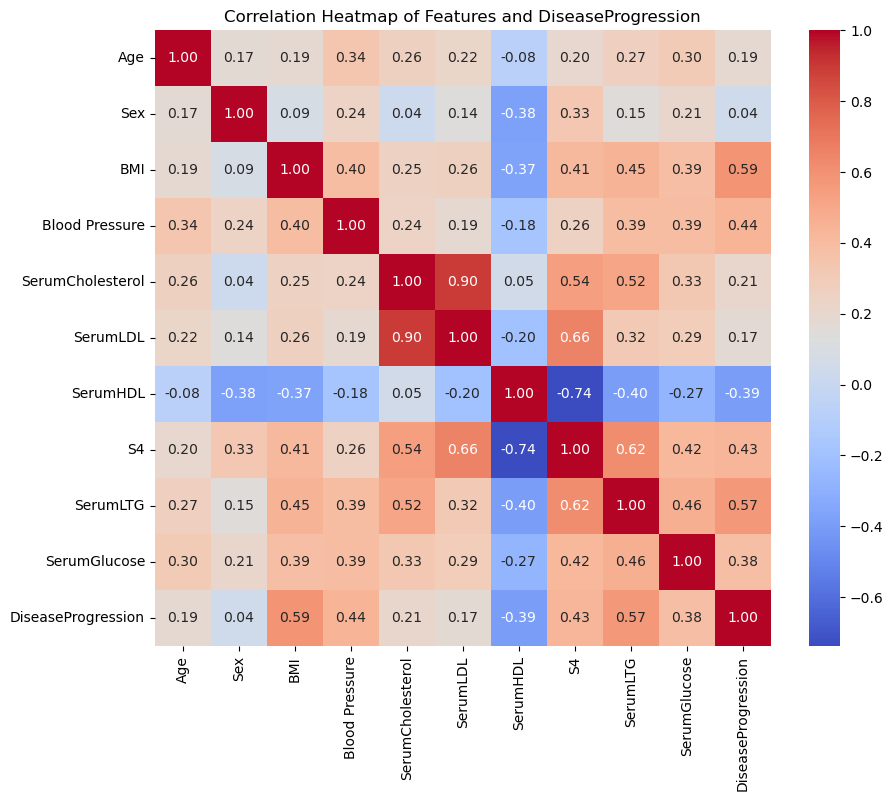

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine features and target for correlation analysis
data_temp = X.copy()
data_temp['DiseaseProgression'] = y  # Ensure column name matches earlier usage

# Compute correlation matrix
corr_matrix = data_temp.corr()

# Display the full correlation matrix
print("\nFull Correlation Matrix:")
print(corr_matrix)

# Generate heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Heatmap of Features and DiseaseProgression')
plt.show()


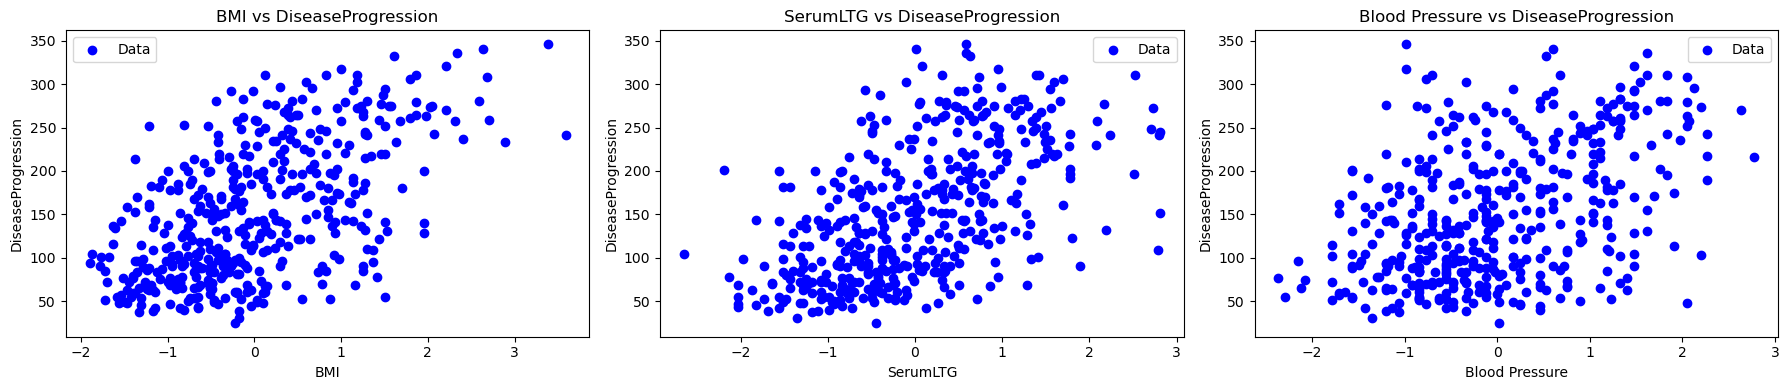

In [25]:
top_features = corr_matrix['DiseaseProgression'].abs().sort_values(ascending=False).index[1:4]
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, feature in enumerate(top_features):
    ax = axes[i]
    ax.scatter(X[feature], y, color='blue', label='Data')
    ax.set_xlabel(feature)
    ax.set_ylabel('DiseaseProgression')
    ax.set_title(f'{feature} vs DiseaseProgression')
    ax.legend()
plt.tight_layout()
plt.show()

In [22]:
from sklearn.model_selection import train_test_split

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print sample sizes
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")


Training samples: 353, Testing samples: 89


In [26]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Model coefficients: [  1.80291044 -23.06446772  25.80070495  16.53858529 -44.30640613
  24.64170961   7.77309591  13.09553713  35.01740872   2.31502709]
Intercept: 185.21175737269556


In [27]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Squared Error (MSE): 2900.19
Root Mean Squared Error (RMSE): 53.85
R² Score: 0.45


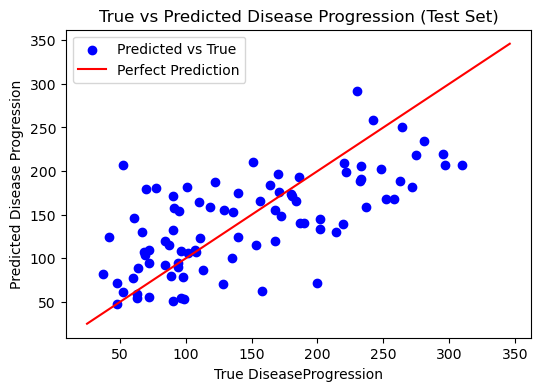

In [28]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs True')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r', label='Perfect Prediction')
plt.xlabel('True DiseaseProgression')
plt.ylabel('Predicted Disease Progression')
plt.title('True vs Predicted Disease Progression (Test Set)')
plt.legend()
plt.show()

In [29]:
highest_corr_feature = corr_matrix['DiseaseProgression'].abs().sort_values(ascending=False).index[1]
X_train_single = X_train[[highest_corr_feature]]
X_test_single = X_test[[highest_corr_feature]]
simple_model = LinearRegression()
simple_model.fit(X_train_single, y_train)
y_pred_single = simple_model.predict(X_test_single)
mse_single = mean_squared_error(y_test, y_pred_single)
rmse_single = np.sqrt(mse_single)
r2_single = r2_score(y_test, y_pred_single)
print(f"\nSimple Regression (using {highest_corr_feature}):")
print(f"MSE: {mse_single:.2f}, R2: {r2_single:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_single:.2f}")
print(f"R² Score: {r2:.2f}")


Simple Regression (using BMI):
MSE: 4061.83, R2: 0.23
Root Mean Squared Error (RMSE): 63.73
R² Score: 0.45


In [ ]:
Correlation and Regression Performance
Correlation measures the strength and direction of a linear relationship between two variables. 
In the context of regression, a feature with a high absolute correlation with the target variable is likely to be a strong predictor in a simple linear regression model.
However, multiple linear regression often outperforms simple regression because it leverages multiple features simultaneously, capturing more complex relationships and interactions.
Even if individual features have moderate correlations, their combined predictive power can significantly improve model accuracy.

Simple regression uses one feature → limited insight.
Multiple regression uses many features → richer, more accurate predictions.